# 📧 NLP Phishing Email Detection

Bidirectional LSTM + Baseline Models + Feature Engineering + Explainability

In [2]:
# CELL 1 — Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

print("All libraries loaded ✅")
print(f"TensorFlow version: {tf.__version__}")

All libraries loaded ✅
TensorFlow version: 2.19.0


In [4]:
from google.colab import files
import io

uploaded = files.upload()
filename = list(uploaded.keys())[0]
df_raw = io.BytesIO(uploaded[filename])
print(f"✅ {filename} uploaded!")

Saving Phishing_Email.csv to Phishing_Email.csv
✅ Phishing_Email.csv uploaded!


## 1. Load & Explore Dataset

In [7]:
# CELL 2 — Load Dataset
df = pd.read_csv(df_raw)
print("Shape:", df.shape)
print(df.head())
print("\nColumn names:", df.columns.tolist())

Shape: (18650, 3)
   Unnamed: 0                                         Email Text  \
0           0  re : 6 . 1100 , disc : uniformitarianism , re ...   
1           1  the other side of * galicismos * * galicismo *...   
2           2  re : equistar deal tickets are you still avail...   
3           3  \nHello I am your hot lil horny toy.\n    I am...   
4           4  software at incredibly low prices ( 86 % lower...   

       Email Type  
0      Safe Email  
1      Safe Email  
2      Safe Email  
3  Phishing Email  
4  Phishing Email  

Column names: ['Unnamed: 0', 'Email Text', 'Email Type']


Email counts:
Email Type
Safe Email        11322
Phishing Email     7328
Name: count, dtype: int64


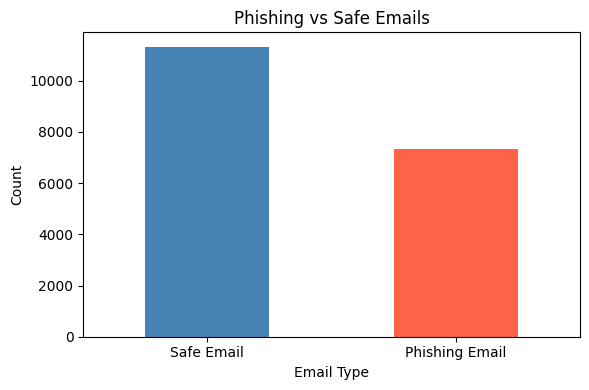


Missing values:
Unnamed: 0     0
Email Text    16
Email Type     0
dtype: int64

Clean dataset size: 18634


In [9]:
# CELL 3 — Explore the Data
print("Email counts:")
print(df['Email Type'].value_counts())

plt.figure(figsize=(6,4))
df['Email Type'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Phishing vs Safe Emails')
plt.xlabel('Email Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('class_distribution.png')
plt.show()

print("\nMissing values:")
print(df.isnull().sum())

# Drop missing
df = df.dropna(subset=['Email Text', 'Email Type']).reset_index(drop=True)
print(f"\nClean dataset size: {len(df)}")

## 2. Label Encoding & Text Cleaning

In [10]:
# CELL 4 — Encode Labels
# Map string labels → binary integers
df['label'] = df['Email Type'].map({'Phishing Email': 1, 'Safe Email': 0})

# Safety check: drop any rows where mapping failed (unknown label values)
before = len(df)
df = df.dropna(subset=['label']).reset_index(drop=True)
df['label'] = df['label'].astype(int)
after = len(df)
if before != after:
    print(f"⚠️  Dropped {before - after} rows with unknown labels")

print("Label distribution:")
print(df['label'].value_counts())
print(df[['Email Type', 'label']].head(5))


Label distribution:
label
0    11322
1     7312
Name: count, dtype: int64
       Email Type  label
0      Safe Email      0
1      Safe Email      0
2      Safe Email      0
3  Phishing Email      1
4  Phishing Email      1


## 3. Feature Engineering

We extract hand-crafted features alongside the text to give models extra signal.

In [11]:
# CELL 5 — Feature Engineering
URGENCY_KEYWORDS = [
    'urgent', 'immediately', 'verify', 'suspend', 'account',
    'click here', 'confirm', 'password', 'bank', 'prize',
    'winner', 'free', 'limited', 'offer', 'expires', 'alert'
]

def extract_features(text):
    text_lower = str(text).lower()
    url_count     = len(re.findall(r'http\S+|www\S+', text_lower))
    email_length  = len(text)
    urgency_count = sum(1 for kw in URGENCY_KEYWORDS if kw in text_lower)
    html_tags     = len(re.findall(r'<[^>]+>', text))
    exclamations  = text.count('!')
    dollar_signs  = text.count('$')
    return pd.Series({
        'url_count'    : url_count,
        'email_length' : email_length,
        'urgency_count': urgency_count,
        'html_tags'    : html_tags,
        'exclamations' : exclamations,
        'dollar_signs' : dollar_signs,
    })

feature_df = df['Email Text'].apply(extract_features)
df = pd.concat([df, feature_df], axis=1)

print("Engineered features added ✅")
print(df[['label','url_count','email_length','urgency_count','html_tags','exclamations','dollar_signs']].groupby('label').mean().round(2))

Engineered features added ✅
       url_count  email_length  urgency_count  html_tags  exclamations  \
label                                                                    
0           1.04       3493.01           0.48       0.17          1.89   
1           0.29       1613.92           1.12       0.02          3.30   

       dollar_signs  
label                
0              1.76  
1              2.23  


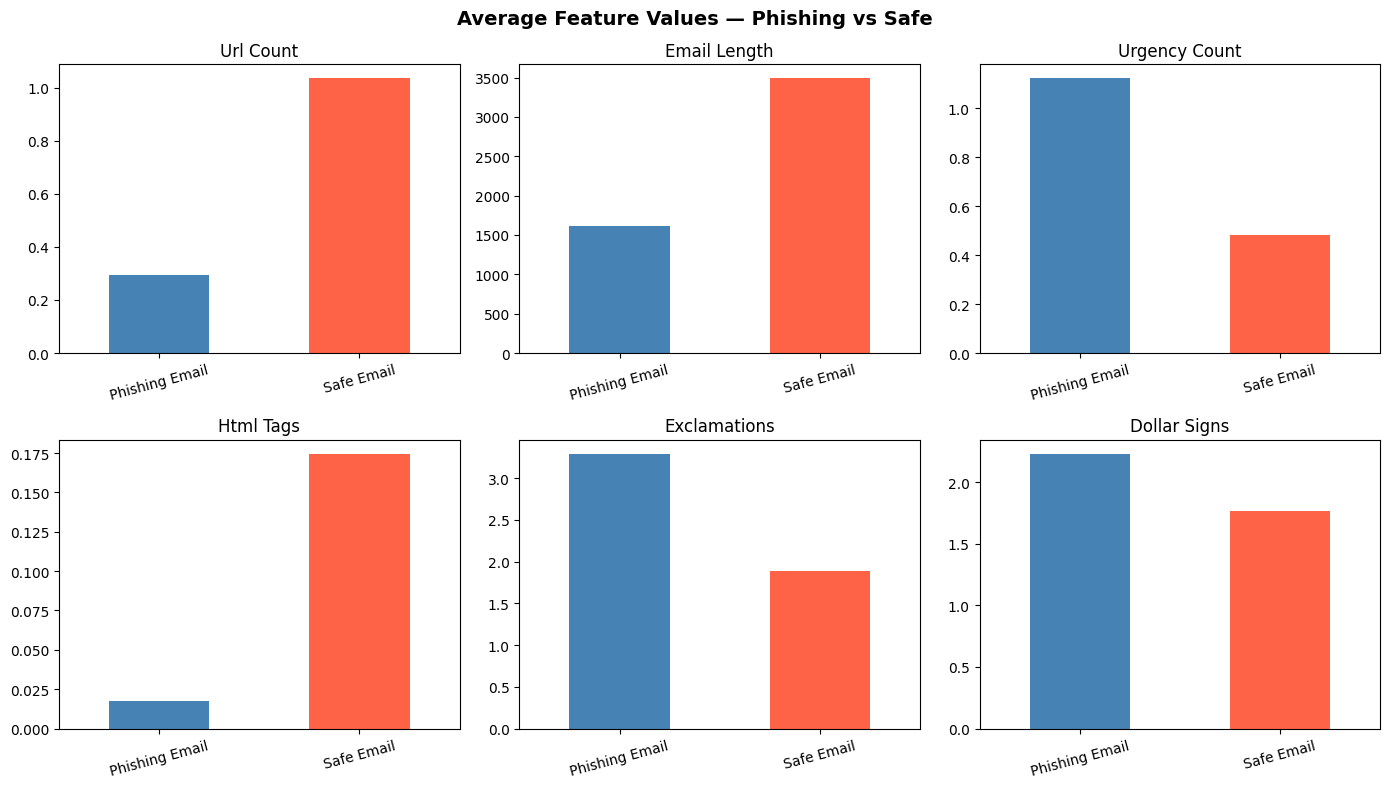

In [12]:
# CELL 6 — Visualise Features by Class
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
feature_cols = ['url_count','email_length','urgency_count','html_tags','exclamations','dollar_signs']

for ax, col in zip(axes.flatten(), feature_cols):
    df.groupby('Email Type')[col].mean().plot(kind='bar', ax=ax, color=['steelblue','tomato'])
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Average Feature Values — Phishing vs Safe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_comparison.png')
plt.show()

In [13]:
# CELL 7 — Text Cleaning
def clean_email(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' url ', text)   # replace URLs
    text = re.sub(r'<.*?>', ' ', text)                      # remove HTML tags
    text = re.sub(r'[^a-z\s]', ' ', text)                  # remove symbols/numbers
    text = re.sub(r'\s+', ' ', text).strip()               # collapse whitespace
    return text

df['clean_text'] = df['Email Text'].apply(clean_email)
print("Cleaning done ✅")
print("Sample cleaned email:")
print(df['clean_text'].iloc[3][:200])

Cleaning done ✅
Sample cleaned email:
hello i am your hot lil horny toy i am the one you dream about i am a very open minded person love to talk about and any subject fantasy is my way of life ultimate in sex play ummmmmmmmmmmmmm i am wet


## 4. Baseline Models (TF-IDF + Logistic Regression / Naive Bayes)

Before training LSTM, we establish simple baselines so we can measure how much deep learning actually helps.

In [14]:
# CELL 8 — Train/Test Split (shared across all models)
# Guard: ensure no NaN labels remain before splitting
assert df['label'].isnull().sum() == 0, "❌ NaN labels found — check Cell 4 mapping!"

X_text = df['clean_text'].values
y      = df['label'].values

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train_text)}  |  Test: {len(X_test_text)}")
print(f"Train phishing: {y_train.sum()} / {len(y_train)}  ({y_train.mean()*100:.1f}%)")
print(f"Test  phishing: {y_test.sum()}  / {len(y_test)}  ({y_test.mean()*100:.1f}%)")


Train: 14907  |  Test: 3727
Train phishing: 5850 / 14907  (39.2%)
Test  phishing: 1462  / 3727  (39.2%)


In [15]:
# CELL 9 — Logistic Regression Baseline
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1,2), sublinear_tf=True)),
    ('clf',   LogisticRegression(max_iter=1000, random_state=42))
])
lr_pipeline.fit(X_train_text, y_train)
y_pred_lr = lr_pipeline.predict(X_test_text)

print("=== Logistic Regression ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr)*100:.2f}%")
print(classification_report(y_test, y_pred_lr, target_names=['Safe', 'Phishing']))

=== Logistic Regression ===
Accuracy: 96.73%
              precision    recall  f1-score   support

        Safe       0.98      0.97      0.97      2265
    Phishing       0.95      0.97      0.96      1462

    accuracy                           0.97      3727
   macro avg       0.96      0.97      0.97      3727
weighted avg       0.97      0.97      0.97      3727



In [16]:
# CELL 10 — Naive Bayes Baseline
nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1,2))),
    ('clf',   MultinomialNB(alpha=0.1))
])
nb_pipeline.fit(X_train_text, y_train)
y_pred_nb = nb_pipeline.predict(X_test_text)

print("=== Naive Bayes ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb)*100:.2f}%")
print(classification_report(y_test, y_pred_nb, target_names=['Safe', 'Phishing']))


=== Naive Bayes ===
Accuracy: 96.16%
              precision    recall  f1-score   support

        Safe       0.97      0.97      0.97      2265
    Phishing       0.95      0.95      0.95      1462

    accuracy                           0.96      3727
   macro avg       0.96      0.96      0.96      3727
weighted avg       0.96      0.96      0.96      3727



## 5. Deep Learning — Bidirectional LSTM

In [17]:
# CELL 11 — Tokenization & Padding
MAX_WORDS = 50000
MAX_LEN   = 300

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_text)   # fit ONLY on train to avoid leakage

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq  = tokenizer.texts_to_sequences(X_test_text)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, truncating='post', padding='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, truncating='post', padding='post')

print(f"Vocabulary size : {len(tokenizer.word_index):,}")
print(f"Train shape     : {X_train_pad.shape}")
print(f"Test shape      : {X_test_pad.shape}")

Vocabulary size : 132,868
Train shape     : (14907, 300)
Test shape      : (3727, 300)


In [18]:
# CELL 12 — Build Bidirectional LSTM Model
model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=128),
    Bidirectional(LSTM(64)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1,  activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
# CELL 13 — Train LSTM
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history = model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.8780 - loss: 0.2641 - val_accuracy: 0.9698 - val_loss: 0.0880
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.9783 - loss: 0.0532 - val_accuracy: 0.9745 - val_loss: 0.0723
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9843 - loss: 0.0325 - val_accuracy: 0.9718 - val_loss: 0.0773
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.9859 - loss: 0.0289 - val_accuracy: 0.9564 - val_loss: 0.0880


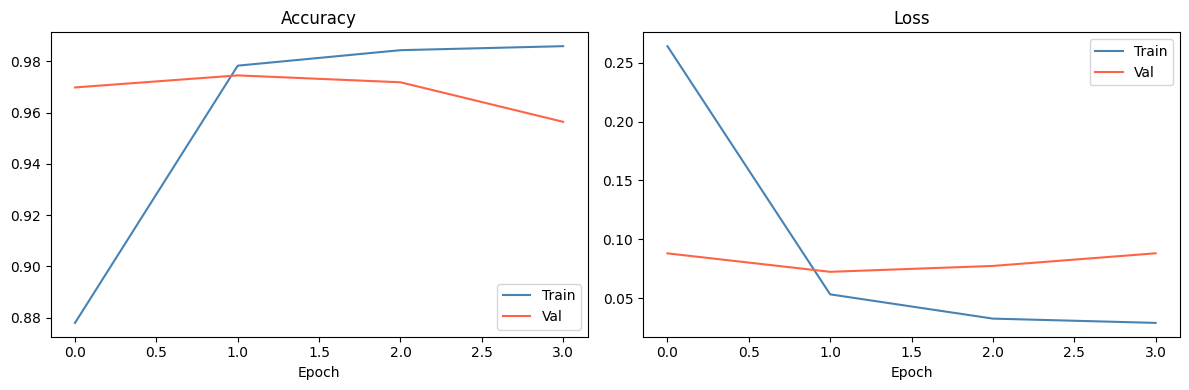

In [20]:
# CELL 14 — Plot Training Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'],     label='Train', color='steelblue')
ax1.plot(history.history['val_accuracy'], label='Val',   color='tomato')
ax1.set_title('Accuracy'); ax1.set_xlabel('Epoch'); ax1.legend()

ax2.plot(history.history['loss'],     label='Train', color='steelblue')
ax2.plot(history.history['val_loss'], label='Val',   color='tomato')
ax2.set_title('Loss'); ax2.set_xlabel('Epoch'); ax2.legend()

plt.tight_layout()
plt.savefig('training_history.png')
plt.show()

LSTM Test Accuracy: 97.16%
117/117 ━━━━━━━━━━━━━━━━━━━━ 11s 90ms/step


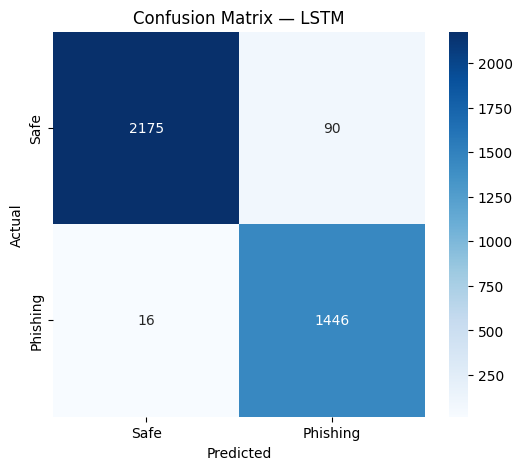


Classification Report:
                precision    recall  f1-score   support

    Safe Email       0.99      0.96      0.98      2265
Phishing Email       0.94      0.99      0.96      1462

      accuracy                           0.97      3727
     macro avg       0.97      0.97      0.97      3727
  weighted avg       0.97      0.97      0.97      3727



In [22]:
# CELL 15 — Evaluate LSTM on Test Set
loss_val, acc_val = model.evaluate(X_test_pad, y_test, verbose=0)
print(f"LSTM Test Accuracy: {acc_val*100:.2f}%")

y_pred_lstm = (model.predict(X_test_pad) > 0.5).astype(int).flatten()

cm = confusion_matrix(y_test, y_pred_lstm)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Safe','Phishing'],
            yticklabels=['Safe','Phishing'])
plt.title('Confusion Matrix — LSTM')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lstm, target_names=['Safe Email','Phishing Email']))

## 6. Model Comparison

Model Accuracy Comparison
-----------------------------------
Bidirectional LSTM     97.16%  ████████████████████████████████████████████████
Logistic Regression    96.73%  ████████████████████████████████████████████████
Naive Bayes            96.16%  ████████████████████████████████████████████████


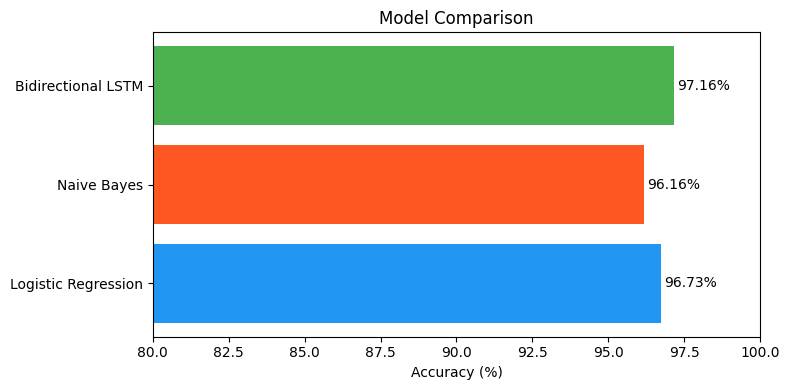

In [23]:
# CELL 16 — Compare All Models
results = {
    'Logistic Regression': accuracy_score(y_test, y_pred_lr) * 100,
    'Naive Bayes'        : accuracy_score(y_test, y_pred_nb) * 100,
    'Bidirectional LSTM' : acc_val * 100,
}

print("Model Accuracy Comparison")
print("-" * 35)
for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    bar = "█" * int(acc // 2)
    print(f"{name:<22} {acc:.2f}%  {bar}")

# Use lists to guarantee bar order matches label order
model_names = list(results.keys())
model_accs  = list(results.values())
colors = ['#2196F3', '#FF5722', '#4CAF50']

plt.figure(figsize=(8, 4))
bars = plt.barh(model_names, model_accs, color=colors)
plt.xlabel('Accuracy (%)')
plt.title('Model Comparison')
plt.xlim(80, 100)
for bar, acc in zip(bars, model_accs):
    plt.text(acc + 0.1, bar.get_y() + bar.get_height()/2,
             f"{acc:.2f}%", va='center')
plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()


## 7. Explainability — Why Is This Email Phishing?

We use the Logistic Regression TF-IDF model to identify the most important words that triggered a phishing prediction.

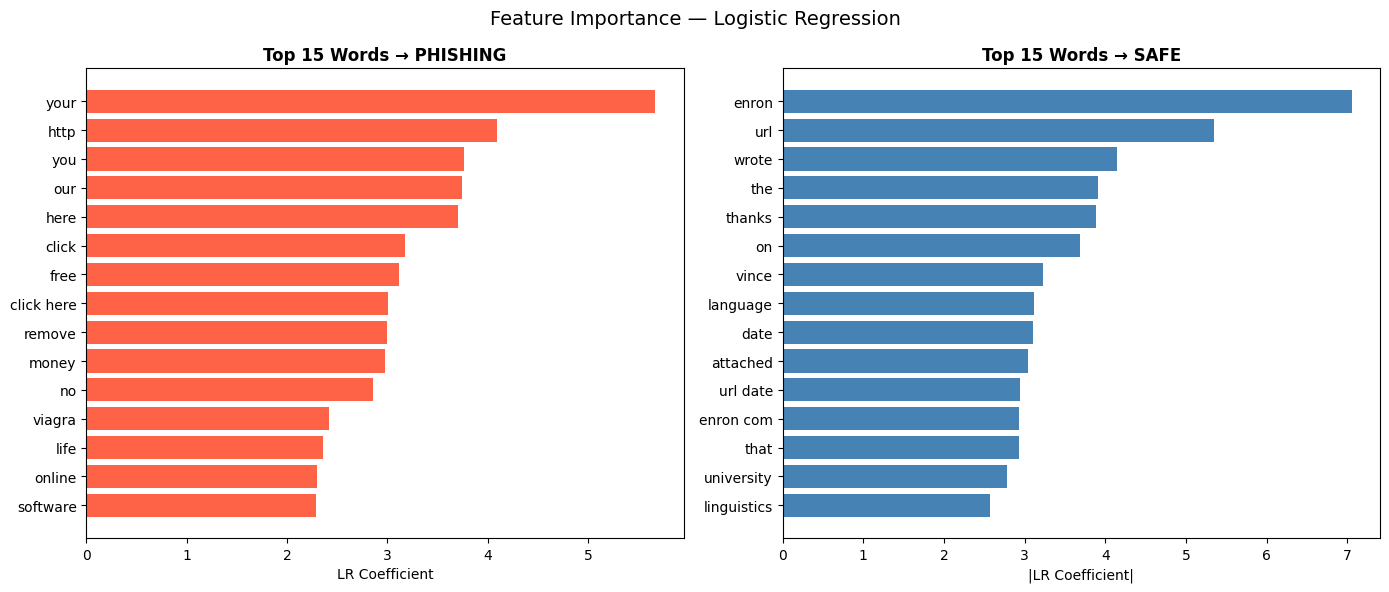

In [24]:
# CELL 17 — Top Phishing / Safe Words (LR Explainability)
tfidf_vec = lr_pipeline.named_steps['tfidf']
lr_model  = lr_pipeline.named_steps['clf']

feature_names = np.array(tfidf_vec.get_feature_names_out())
coefficients  = lr_model.coef_[0]

# Top 15 words pushing toward PHISHING (positive coef) and SAFE (negative coef)
top_phishing_idx = np.argsort(coefficients)[-15:][::-1]
top_safe_idx     = np.argsort(coefficients)[:15]

top_phishing_words = feature_names[top_phishing_idx]
top_phishing_vals  = coefficients[top_phishing_idx]
top_safe_words     = feature_names[top_safe_idx]
top_safe_vals      = coefficients[top_safe_idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.barh(top_phishing_words[::-1], top_phishing_vals[::-1], color='tomato')
ax1.set_title('Top 15 Words → PHISHING', fontsize=12, fontweight='bold')
ax1.set_xlabel('LR Coefficient')

ax2.barh(top_safe_words[::-1], np.abs(top_safe_vals[::-1]), color='steelblue')
ax2.set_title('Top 15 Words → SAFE', fontsize=12, fontweight='bold')
ax2.set_xlabel('|LR Coefficient|')

plt.suptitle('Feature Importance — Logistic Regression', fontsize=14)
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

In [25]:
# CELL 18 — Per-Email Explainability

def explain_prediction(email_text, top_n=8):
    """Shows which words most influenced the phishing/safe prediction."""
    cleaned = clean_email(email_text)

    prob_phishing = lr_pipeline.predict_proba([cleaned])[0][1]
    pred_label    = "🚨 PHISHING" if prob_phishing > 0.5 else "✅ SAFE"

    tfidf_vec  = lr_pipeline.named_steps['tfidf']
    lr_model   = lr_pipeline.named_steps['clf']
    feat_names = np.array(tfidf_vec.get_feature_names_out())
    coefs      = lr_model.coef_[0]

    vec = tfidf_vec.transform([cleaned])          # sparse matrix (1 x vocab)
    vec_array   = vec.toarray()[0]                # convert to dense safely
    nonzero_idx = np.nonzero(vec_array)[0]        # indices of present words

    word_scores = [
        (feat_names[i], float(coefs[i] * vec_array[i]))
        for i in nonzero_idx
    ]
    word_scores = sorted(word_scores, key=lambda x: abs(x[1]), reverse=True)[:top_n]

    print(f"Email preview : {email_text[:120]}...")
    print(f"Prediction    : {pred_label}  (phishing probability: {prob_phishing:.2%})")
    print("\nTop contributing words:")
    for word, score in word_scores:
        direction = "→ PHISHING" if score > 0 else "→ SAFE"
        print(f"  {word:<20}  score={score:+.4f}  {direction}")
    print("-" * 60)

print("=== PHISHING SAMPLE ===")
explain_prediction(df[df['label']==1]['Email Text'].iloc[10])

print("\n=== SAFE SAMPLE ===")
explain_prediction(df[df['label']==0]['Email Text'].iloc[10])


=== PHISHING SAMPLE ===
Email preview : premium adult content looking for high quality adult content at the right price ? then check out xxx by scarlett - 15 im...
Prediction    : 🚨 PHISHING  (phishing probability: 93.05%)

Top contributing words:
  quality               score=+0.3374  → PHISHING
  adult                 score=+0.2775  → PHISHING
  your                  score=+0.2297  → PHISHING
  the                   score=-0.2197  → SAFE
  you                   score=+0.2109  → PHISHING
  our                   score=+0.1847  → PHISHING
  english               score=-0.1478  → SAFE
  hardcore              score=+0.1371  → PHISHING
------------------------------------------------------------

=== SAFE SAMPLE ===
Email preview : re : testing ir & fx var nick and winston , i understand that ir & fx var numbers are calculated every day in risktrac ....
Prediction    : ✅ SAFE  (phishing probability: 20.46%)

Top contributing words:
  the                   score=-0.3118  → SAFE
  results   

## 8. Final Demo — Predict Any Email

In [26]:
# CELL 19 — Demo Function
# BUG FIX: original code used `if actual_label:` which fails silently
# when actual_label="SAFE" is falsy in some edge cases.
# Correct check is `if actual_label is not None:`

def predict_email(email_text, actual_label=None):
    """Predict whether a raw email text is phishing or safe."""
    cleaned    = clean_email(email_text)
    seq        = tokenizer.texts_to_sequences([cleaned])
    padded_seq = pad_sequences(seq, maxlen=MAX_LEN, padding='post')
    raw_score  = model.predict(padded_seq, verbose=0)[0][0]

    if raw_score > 0.5:
        result     = "🚨 PHISHING DETECTED"
        confidence = raw_score
    else:
        result     = "✅ SAFE EMAIL"
        confidence = 1 - raw_score

    if actual_label is not None:   # FIX: was `if actual_label:` — broken for "SAFE" edge cases
        print(f"Actual    : {actual_label}")
    print(f"Predicted : {result} ({confidence:.2%} confidence)")
    print(f"Preview   : {email_text[:100]}")
    print("-" * 60)

print("=== PHISHING EMAILS ===")
for i in [5, 10, 15]:
    predict_email(df[df['label']==1]['Email Text'].iloc[i], actual_label="PHISHING")

print("\n=== SAFE EMAILS ===")
for i in [5, 10, 15]:
    predict_email(df[df['label']==0]['Email Text'].iloc[i], actual_label="SAFE")


=== PHISHING EMAILS ===
Actual    : PHISHING
Predicted : 🚨 PHISHING DETECTED (99.95% confidence)
Preview   : formal invite for chase . secrets revealed . how do porn stars perform , stay strong and hard even a
------------------------------------------------------------
Actual    : PHISHING
Predicted : 🚨 PHISHING DETECTED (99.98% confidence)
Preview   : premium adult content looking for high quality adult content at the right price ? then check out xxx
------------------------------------------------------------
Actual    : PHISHING
Predicted : 🚨 PHISHING DETECTED (99.93% confidence)
Preview   : gino , who do u want to win ? the secret on how porn stars grew big dicks ! the answer is here . tur
------------------------------------------------------------

=== SAFE EMAILS ===
Actual    : SAFE
Predicted : ✅ SAFE EMAIL (99.97% confidence)
Preview   : re : coastal deal - with exxon participation under the project agreement thanks for the info ! as gr
---------------------------------------

In [27]:
# CELL 20 — Try Your Own Email
my_email = """
Dear user, your account has been suspended.
Click here immediately to verify your details and avoid permanent suspension.
Confirm your password at: http://secure-login.fakebank.com
"""

print("Custom email test:")
predict_email(my_email)
print()
explain_prediction(my_email)

Custom email test:
Predicted : 🚨 PHISHING DETECTED (99.94% confidence)
Preview   : 
Dear user, your account has been suspended. 
Click here immediately to verify your details and avoi
------------------------------------------------------------

Email preview : 
Dear user, your account has been suspended. 
Click here immediately to verify your details and avoid permanent suspensi...
Prediction    : 🚨 PHISHING  (phishing probability: 93.46%)

Top contributing words:
  your                  score=+0.9651  → PHISHING
  url                   score=-0.5629  → SAFE
  click here            score=+0.4745  → PHISHING
  click                 score=+0.4364  → PHISHING
  here                  score=+0.3879  → PHISHING
  account               score=+0.2483  → PHISHING
  your account          score=+0.2476  → PHISHING
  permanent             score=+0.2375  → PHISHING
------------------------------------------------------------


## 9. Save Model

In [28]:
# CELL 21 — Save LSTM Model (use .keras format to avoid deprecation warning)
model.save('lstm_phishing_model.keras')
print("LSTM model saved ✅")

# Save tokenizer
import pickle
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("Tokenizer saved ✅")

# Save LR pipeline
with open('lr_pipeline.pkl', 'wb') as f:
    pickle.dump(lr_pipeline, f)
print("LR pipeline saved ✅")

LSTM model saved ✅
Tokenizer saved ✅
LR pipeline saved ✅
